In [241]:
# class 고안
# 그리고 풀어서 코드써보삼 (스스로)
# 모델 내부 구조 이해

In [225]:
import warnings
warnings.filterwarnings('ignore')

In [226]:
# 목표: 반려동물이 입양되는지 예측
# 내 목표는 코드 작동원리를 이해하는가

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers

In [227]:
dataframe = pd.read_csv('datasets/petfinder_mini_extracted/petfinder-mini/petfinder-mini.csv')
dataframe.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,Nibble is a 3+ month old ball of cuteness. He ...,1,2
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,I just found it alone yesterday near my apartm...,2,0
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,Their pregnant mother was dumped by her irresp...,7,3
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,"Good guard dog, very alert, active, obedience ...",8,2
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,This handsome yet cute boy is up for adoption....,3,2


In [228]:
# 표 정리

dataframe['target'] = np.where(dataframe["AdoptionSpeed"]==4, 0, 1)
# np.where(조건, 참일 때 값, 거짓일 때 값)
dataframe = dataframe.drop(columns=['AdoptionSpeed', 'Description'])

dataframe.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,PhotoAmt,target
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,1,1
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,2,1
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,7,1
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,8,1
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,3,1


In [229]:
train, val, test = np.split(dataframe.sample(frac=1), [int(0.8*(len(dataframe))), int(0.9*len(dataframe))])
# dataframe.sample(frac=1) 나누기전에 섞기.
# (샘플링은 뽑다/ 추출하다 인데 특징이 무작위로 뽑는거라서 셔플이랑 다를 게 없다.(pandas에선 이걸쓰삼. tf에서는 셔플))
# (frac은 비율의 약자. 0.5는 50%, 1은 100%)
# split은 칼자국.

# train = train.reset_index(drop=True) # 인덱스 재정렬
# drop=True는 옛날 번호표들 버려도된다는뜻.

print(len(train))
print(len(val))
print(len(test))

9229
1154
1154


In [ ]:
# 데이터셋으로 가공 ! !
def df_to_dataset(dataframe, shuffle=True, batch_size=32):
    df = dataframe.copy()
    labels = df.pop('target')
    df = {key : value.to_numpy()[:, tf.newaxis] for key, value in dataframe.items()}
    
    ds = tf.data.Dataset.from_tensor_slices((dict(df), labels))
    # tf.data.Dataset.from_tensor_slices(문제, 정답) 이렇게 하면 
    # 결과물이 ((나이: 성별: 어쩌구:), 정답:) 이롷게 묶어서 줌. (이게 데이터셋)
    
    # 텐서란. 데이터를 담는 다차원 배열
    # 데이터셋은 사람1데이터들, 사람2데이터들... 
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(batch_size)
    return ds

In [231]:
# 확인용 예시
# batch_size = 5
# train_ds = df_to_dataset(train, batch_size=batch_size)

# [(train_features, label_batch)] = train_ds.take(1)
# print(list(train_features.keys()))
# print(train_features['Age'])
# print(label_batch)

In [232]:
# for x, y in train_ds.take(1):
    # print(x)
    # print(y)

이 코드 안에서 아래 네 개의 전처리 레이어를 사용한다.

| Keras 전처리 레이어 | 설명 |
|:---|:---|
| tf.keras.layers.Normalization | 정규화수행. 데이터 분포를 표준화한다. |
| tf.keras.layers.CategoryEncoding | 정수를 원-핫, 멀티-핫 또는 TF-IDF으로 바꾼다. |
| tf.keras.layers.StringLookup | 문자열 범주형 값 -> 정수 인덱스 |
| tf.keras.layers.IntegerLookup | 정수 범주형 값 -> 정수 인덱스 |


In [233]:
# 숫자열
# 데이터 분포 표준화
def get_normalization_layer(name, dataset):
    
    # 특징 네임텍들이 차원이 있지는 않다.
    nomalizer = layers.Normalization(axis=None)
    
    feature_ds = dataset.map(lambda x, y: x[name])
    
    nomalizer.adapt(feature_ds) # 기준 잡기 (미리 간보기 작업)
    
    return nomalizer

In [234]:
# photo_count_col = train_features['PhotoAmt']
# layer = get_normalization_layer('PhotoAmt', train_ds)
# layer(photo_count_col)

- **숫자 특성이 많은 경우(수백 개 이상) 먼저 숫자 특성을 연결하고 단일 tf.keras.layers.Normalization 레이어를 사용하는 것이 더 효율적이다.**

In [235]:
# 범주열
# 멀티 핫 인코딩
def get_category_encoding_layer(name, dataset, dtype, max_tokens=None):
    if dtype == 'string':
        index = layers.StringLookup(max_tokens=max_tokens)
    else:
        index = layers.IntegerLookup(max_tokens=max_tokens)
        
    feature_ds = dataset.map(lambda x, y: x[name])
    index.adapt(feature_ds)
    encoder = layers.CategoryEncoding(num_tokens=index.vocabulary_size())
    
    return lambda feature: encoder(index(feature)) 
# 나중에 진짜 데이터 들어오면 인덱스붙이기 -> 인코더 순으로 작업하고 내보내라는 지시서.
# 위 숫자열 할 때에는 한 개의 기계만 사용했으니 lambda사용해서 리턴하지 않아도 됨.
# 연속 동작 지시할 때에는 lambda

In [236]:
# test_type_col = train_features['Type']
# test_type_layer = get_category_encoding_layer(name='Type',
                                              # dataset=train_ds,
                                              # dtype='string')
# test_type_layer(test_type_col)

In [237]:
# test_age_col = train_features['Age']
# test_age_layer = get_category_encoding_layer(name='Age',
                                             # dataset=train_ds,
                                             # dtype='int64',
                                             # max_tokens=5)
# test_age_layer(test_age_col)

숫자형: **('PhotoAmt', 'Fee')** -큰 수 위주

범주형: **('Age', 'Type', 'Color1', 'Color2', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Breed1')**

---

참조: 목표가 정확한 모델을 빌드하는 것이라면 의미있는 특성과 표현 방법에 대해 신중히 고민하기.

In [238]:
# 본격적 특성 전처리 (모델을 훈련하기 위해)

batch_size = 256
train_ds = df_to_dataset(train, batch_size=batch_size)
val_ds = df_to_dataset(val, shuffle=False, batch_size=batch_size)
test_ds = df_to_dataset(test, shuffle=False, batch_size=batch_size)

In [239]:
all_inputs = []
encoded_features = []


# ---
# 숫자형
for header in ['PhotoAmt', 'Fee']:
    numeric_col = tf.keras.Input(shape=(1,), name=header)
    normalization_layer = get_normalization_layer(header, train_ds)
    encoded_numeric_col = normalization_layer(numeric_col)
    
    all_inputs.append(numeric_col)
    encoded_features.append(encoded_numeric_col)

In [240]:
# 범주형
age_col = tf.keras.Input(shape=(1,), name='Age', dtype='int64') # 데이터가 들어올 입구(규격)을 정의하는 것.
encoding_layer = get_category_encoding_layer(name='Age',
                                             dataset=train_ds,
                                             dtype='int64',
                                             max_tokens=5)

encoded_age_col = encoding_layer(age_col)

all_inputs.append(age_col)
encoded_features.append(encoded_age_col)


#---
categorical_cols = ['Type', 'Color1', 'Color2', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Breed1']
for header in categorical_cols:
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
    encoding_layer = get_category_encoding_layer(name=header,
                                                 dataset=train_ds,
                                                 dtype='string',
                                                 max_tokens=5)
    encoded_categorical_col = encoding_layer(categorical_col)
    
    all_inputs.append(categorical_col)
    encoded_features.append(encoded_categorical_col)

- 모델 생성 -> 컴파일 -> 훈련 -> 테스트

In [242]:
# 모델 생성
all_features = tf.keras.layers.concatenate(encoded_features) # 하나의 벡터로 병합하기.

x = tf.keras.layers.Dense(32, activation="relu")(all_features) # Dense의 일: 정보 버무려서 32개의 새로운 정보 덩어리 만들어내기.
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(all_inputs, output)

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), 
              # 로짓: 날것의점수 를 BinaryCrossentropy가 시그모이드확률로 바꿔 채점해줌.
              metrics="accuracy") # 관전 포인트

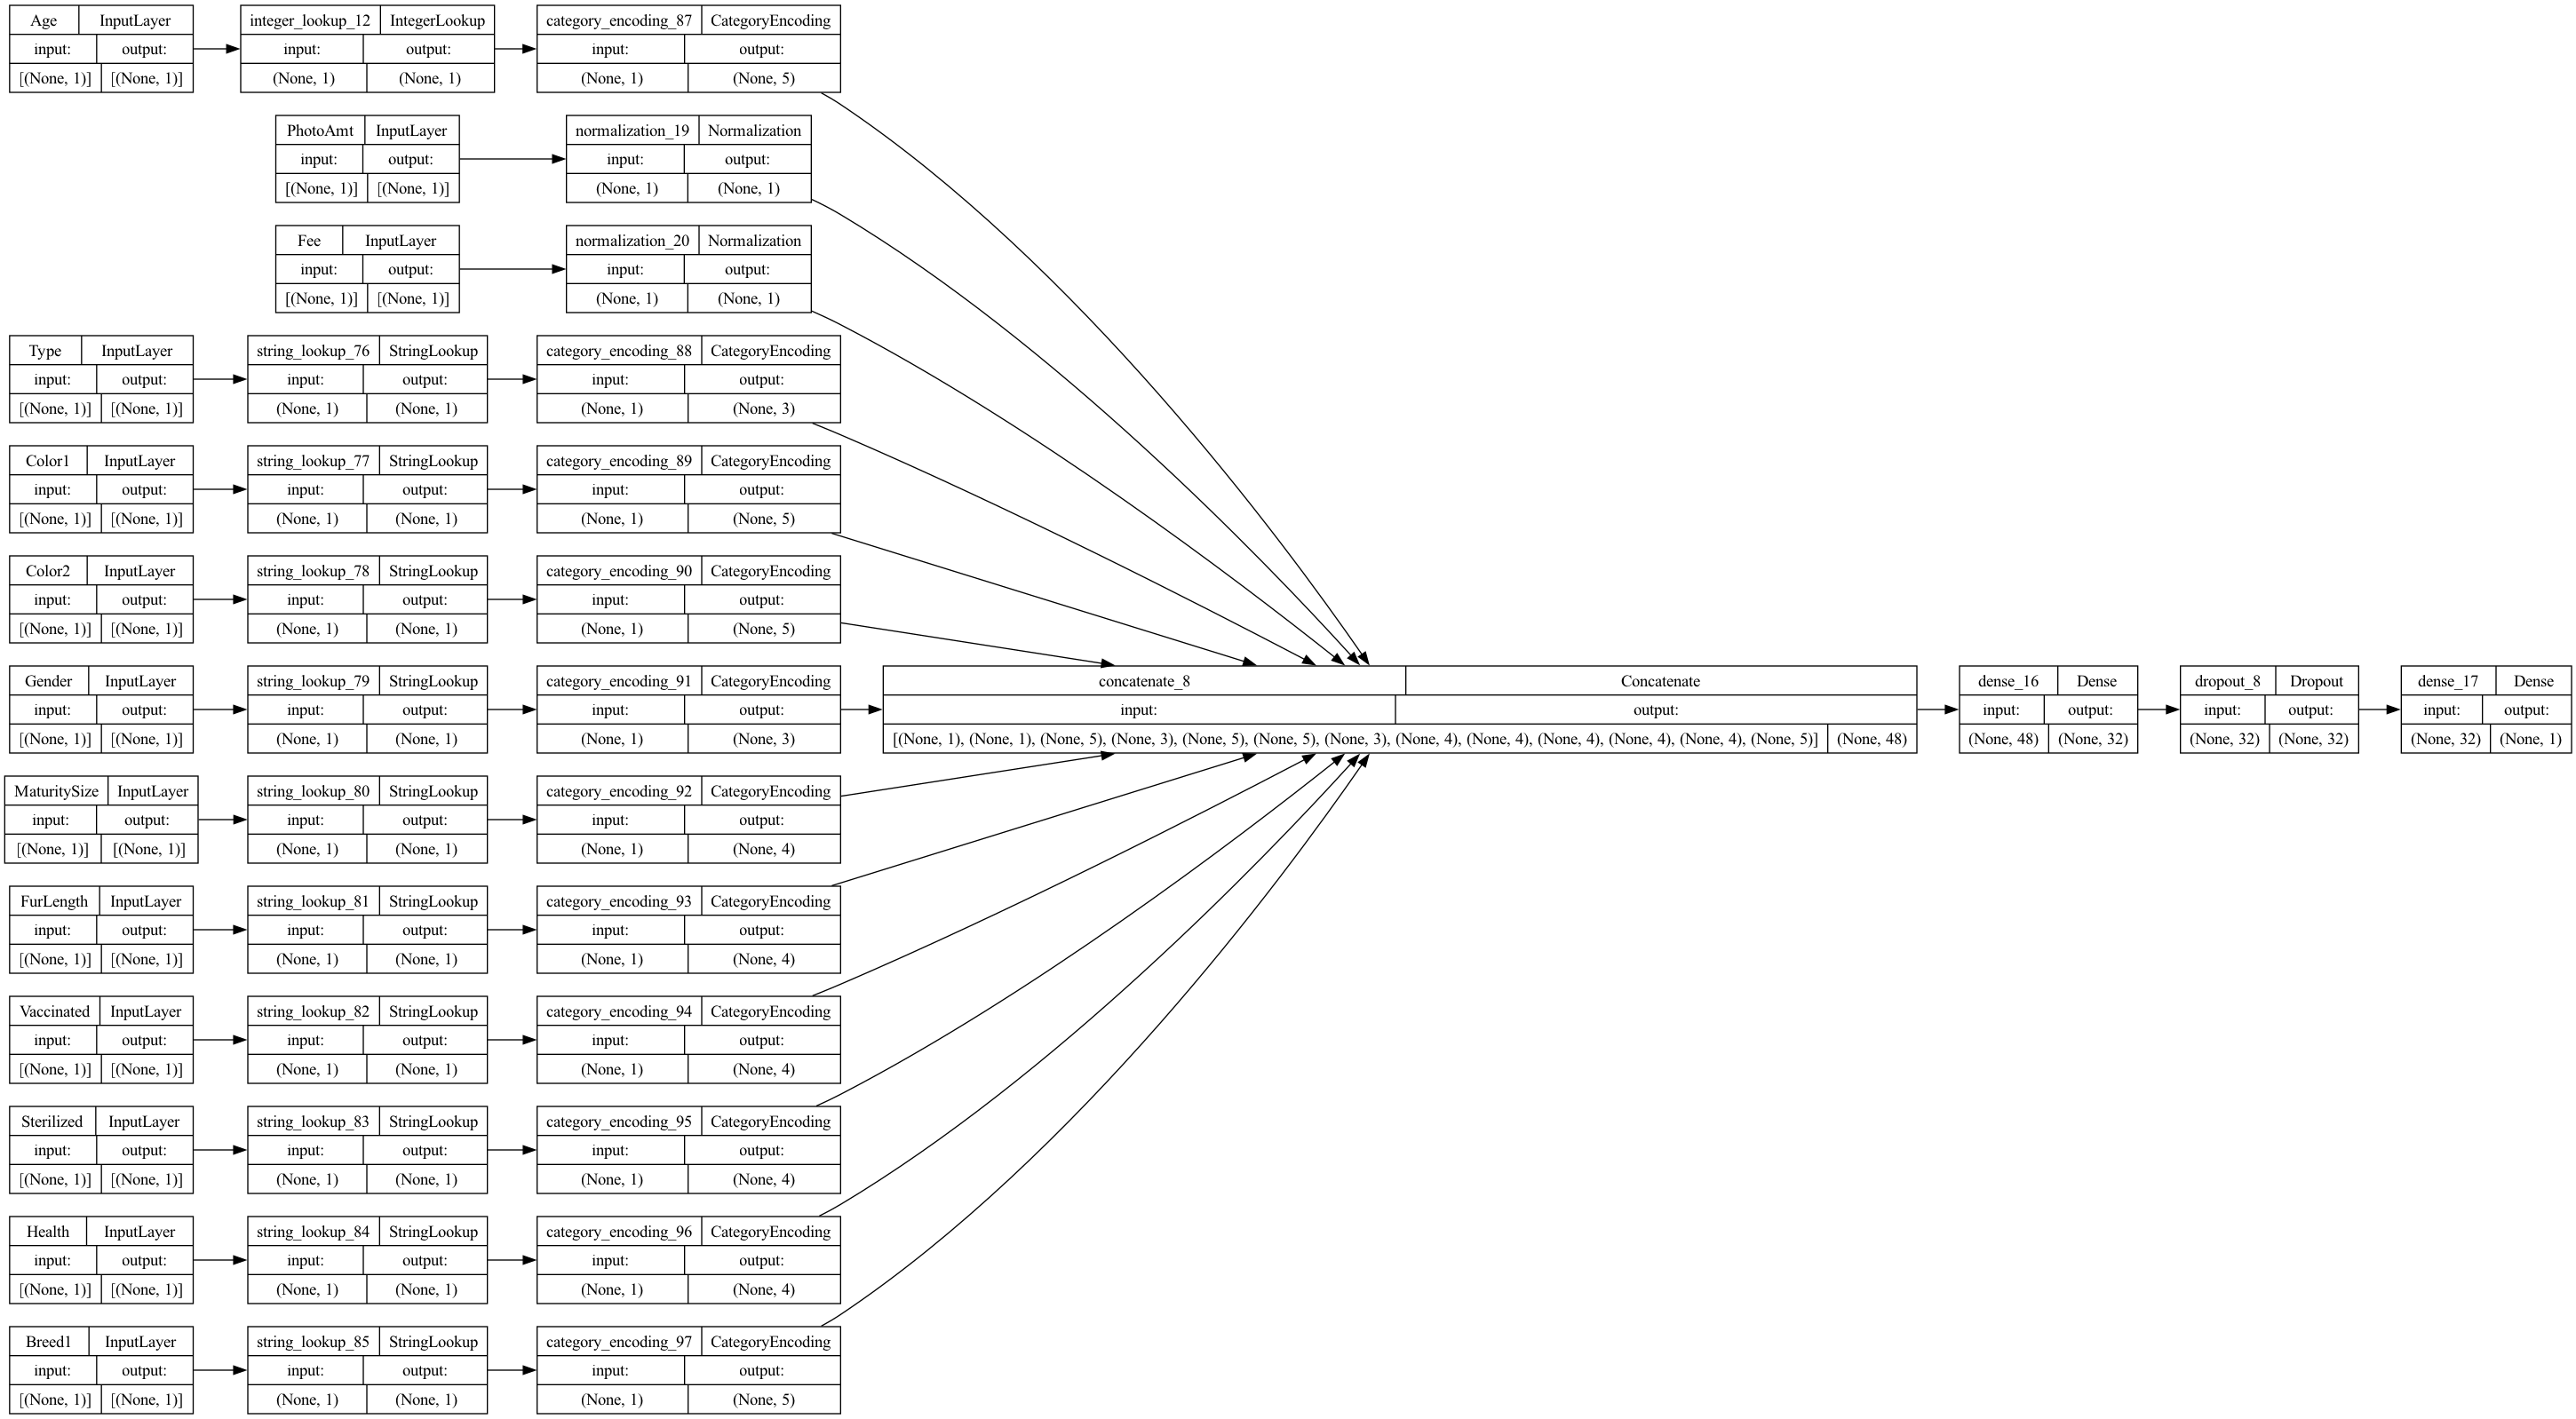

In [244]:
# 연결 그래프 시각화
tf.keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [245]:
training_recode = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
37/37 [==============================] - 3s 44ms/step - loss: 0.6698 - accuracy: 0.5773 - val_loss: 0.6055 - val_accuracy: 0.6898
Epoch 2/10
37/37 [==============================] - 1s 17ms/step - loss: 0.6071 - accuracy: 0.6558 - val_loss: 0.5800 - val_accuracy: 0.6811
Epoch 3/10
37/37 [==============================] - 1s 18ms/step - loss: 0.5867 - accuracy: 0.6758 - val_loss: 0.5682 - val_accuracy: 0.6915
Epoch 4/10
37/37 [==============================] - 1s 21ms/step - loss: 0.5728 - accuracy: 0.6819 - val_loss: 0.5606 - val_accuracy: 0.6802
Epoch 5/10
37/37 [==============================] - 1s 25ms/step - loss: 0.5589 - accuracy: 0.6964 - val_loss: 0.5553 - val_accuracy: 0.6828
Epoch 6/10
37/37 [==============================] - 1s 27ms/step - loss: 0.5486 - accuracy: 0.7059 - val_loss: 0.5520 - val_accuracy: 0.6915
Epoch 7/10
37/37 [==============================] - 1s 26ms/step - loss: 0.5387 - accuracy: 0.7115 - val_loss: 0.5507 - val_accuracy: 0.6984
Epoch 8/10
37

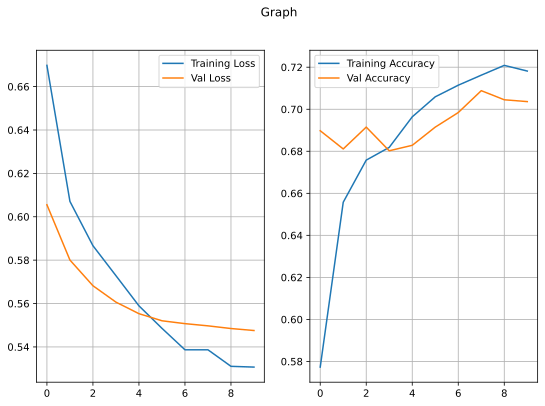

In [246]:
# 학습 곡선 시각화 (손실/ 정확도)
fig, axes = plt.subplots(ncols=2, figsize=(9,6))
fig.suptitle("Graph")
for idx, ax in enumerate(axes):
    ax.grid()
    if idx == 0:
        ax.plot(training_recode.history["loss"], label="Training Loss")
        ax.plot(training_recode.history["val_loss"], label="Val Loss")
    else:
        ax.plot(training_recode.history["accuracy"], label="Training Accuracy")
        ax.plot(training_recode.history["val_accuracy"], label="Val Accuracy")
    ax.legend()
plt.show()

In [247]:
loss, accuracy = model.evaluate(test_ds)

print("Accuracy", accuracy)
print("Loss", loss)

5/5 [==============================] - 0s 16ms/step - loss: 0.5004 - accuracy: 0.7487
Accuracy 0.7487002015113831
Loss 0.500386655330658


In [248]:
# 새 데이터에 대한 추론을 수행하기 전에 저장/ 로드하기
# model.save('my_pet_classifier')
# reloaded_model = tf.keras.models.load_model('my_pet_classifier.keras')

---

새 샘플에 대한 예측값을 얻으려면 Keras Model.predict() 메서드 호출하면 됨.

다음 두 가지를 수행함

1. 배치 차원을 갖도록 스칼라를 목록으로 래핑합니다. (Model은 단일 샘플이 아닌 데이터 배치만 처리함)

2. 각 특성에 대해 tf.convert_to_tensor 를 호출

In [ ]:
sample = {
    'Type': 'Cat',
    'Age': 3,
    'Breed1': 'Tabby',
    'Gender': 'Male',
    'Color1': 'Black',
    'Color2': 'White',
    'MaturitySize': 'Small',
    'FurLength': 'Short',
    'Vaccinated': 'No',
    'Sterilized': 'No',
    'Health': 'Healthy',
    'Fee': 100,
    'PhotoAmt': 2,
}

# 그냥 단일 스칼라값을 [이렇게 리스트로 감싸 1개입 상자로 만들기]
input_dict = {name : tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)
prob = tf.nn.sigmoid(predictions[0]) # nn(Neural Network라는 뜻.) 약간 tf.keras.activations메서드랑 비슷

print(
    "입양될 확률은 %.1f 퍼입니다." % (100 * prob)
)

1/1 [==============================] - 0s 339ms/step
입양될 확률은 77.3 퍼입니다.


---

이 PetFinder.my 데이터세트와 같은 작은 데이터세트로 작업할 때에는 **의사 결정 트리** 또는 **랜덤 포레스트**를 쓰는 것이 더 좋다.

더 크고 복잡한 데이터세트로는 딥러닝.

지금까지 처리 메커니즘을 공부한 것.